## **Rossler Netowrk Model Learned by SREINet**

A sparse network including non-local connections and high-order interactions 


## **I. Setup and Preprocessing**

In [1]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG


# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

Network loaded: 34 nodes, 78 edges, 45 triangles
Loaded network with 34 nodes


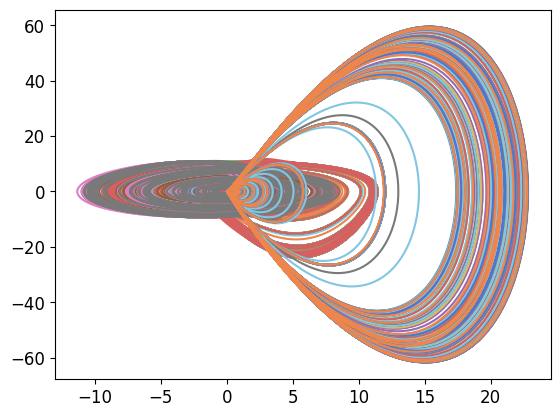

Training input shape: (30000, 102)
Training output shape: (30000, 102)


In [12]:
# Specify the model type
from rossler_hoi import *

from network_loader import load_zachary_network

MY_DATA_TYPE = 'float32'

# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  

# Generate data based on the specified model type

network_data, edge_list, triangle_list, N = load_zachary_network()
    
print(f"Loaded network with {N} nodes")
# Generate random initial conditions
np.random.seed(42)
num_traj = 6

inintial_conditions = []
for i in range(num_traj):
    x0 =  np.random.rand(N) 
    y0 =  np.random.rand(N) 
    z0 =  np.random.rand(N)
    new_IC = np.concatenate([x0, y0, z0])
    inintial_conditions.append(new_IC)

data_T = 50.0       # Length of the data (T)
data_dt = 0.01       # Resolution of the data (dt)
myDG = DG.DataGenerator(inintial_conditions,T=data_T, dt=data_dt, derivative_mode="exact")

t_arr, x_train, dx_train = myDG.generate_dataset_by_custom_ODEs(rossler_hoi, edge_list, triangle_list, method='DOP853')


#x_train_mean = np.mean(x_train, axis=0)
#x_train_std = np.std(x_train, axis=0) + 1e-8

#x_train_standardized = (x_train - x_train_mean) / x_train_std

# Scale dx by the same std (preserving the derivative relationship)
#dx_train_standardized = dx_train / x_train_std


#x_train = x_train_standardized
#dx_train = dx_train_standardized

#plot x_train and dx_train
import matplotlib.pyplot as plt
plt.plot(x_train, dx_train)
plt.show()

#Shuffle data
training_input, training_output = x_train, dx_train
# Optionally, save a copy of the training input for simulation
#training_input_for_sim = training_input.copy() # Saving a copy of training input for simulation (Before shuffling)

#training_input, training_output = myDG.shuffleData(training_input, training_output)

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

### **1.3 Hyperparameters**


In [13]:
# Set mini-batch size
MINI_BATCH_SIZE = 32
learning_rate = 0.001

### **1.4 Model Architecture Definitions**


**SREINet Parameters**

In [14]:
# Assign dim to be the 2nd dimension of the training data (number of input variables)
dim = training_input.shape[1] 

guessed_multiplicative_order = 3
# The grid size of each dimension
layer_depth = guessed_multiplicative_order
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn) # these numbers exclude the constant term

[102, 102, 102]


## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [15]:
my_activation = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn,
                     activations=my_activation,
                     weight_initializer=tf.initializers.random_normal(stddev=1e-5, seed=42),
                     data_type=MY_DATA_TYPE,
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)


### **2.2 Loss Function**

In [ ]:
LOSS_FUNCTION = 'lasso' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION, l1_regularization_strength=1e-7) 

### **2.3 Optimizer**

In [17]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Trainer**


In [18]:
np.set_printoptions(threshold=np.inf)

from sreinet_trainer import SREINetTrainer

trainer = SREINetTrainer(
    model,
    my_optimizer,
    loss_fn,
    data_type=MY_DATA_TYPE,
    random_seed=42,
)


## **III.Training the Model**

#### **Pruning Profile**

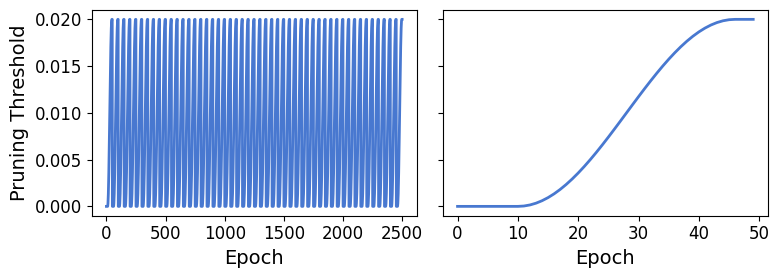

In [19]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.02 #Threshold for 10D Lorenz 96 model. Uses linear prune schedule
N_PERIODS = 50
PRUNING_EPOCHS_PER_PERIOD = 50
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

pruning_scheduler = ps.PruningScheduler(
    steps_per_period=PRUNING_EPOCHS_PER_PERIOD,
    num_periods=N_PERIODS,
    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
    show_plot=True,
)


### Training

In [20]:
#Setup
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 1e-10   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.005

training_histories = []
weights_list = []

In [21]:
#change 0 to a other number if you want to start training from other dimensions
for i in range(0, training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    trainer.reset_trainer_and_model_weights(i)
    output = training_output[:, i:i+1]

    history = trainer.fit(
        training_input,
        output,
        batch_size=MINI_BATCH_SIZE,
        validation_split=0.20,
        epochs=round(NUM_EPOCHS),
        pruning_scheduler=pruning_scheduler,
        callbacks=callbacks,
        early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
        early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
        shuffle_per_epoch=False,
        patience_periods=15,
        verbose=1,
    )

    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])


Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 7.727e+01,  Validation Loss: 3.072e+00,  Epoch Time: 0.73s,  Current Pruning Threshold: 0
Epoch   2 (Period 1):  Train Loss: 2.569e+00,  Validation Loss: 1.283e+00,  Epoch Time: 0.59s,  Current Pruning Threshold: 0
Epoch   3 (Period 1):  Train Loss: 3.950e-01,  Validation Loss: 4.833e-02,  Epoch Time: 0.60s,  Current Pruning Threshold: 0
Epoch   4 (Period 1):  Train Loss: 5.494e+05,  Validation Loss: 1.552e+02,  Epoch Time: 0.65s,  Current Pruning Threshold: 0
Epoch   5 (Period 1):  Train Loss: 1.038e+02,  Validation Loss: 6.675e+01,  Epoch Time: 0.61s,  Current Pruning Threshold: 0
Epoch   6 (Period 1):  Train Loss: 6.938e+01,  Validation Loss: 5.375e+01,  Epoch Time: 0.59s,  Current Pruning Threshold: 0
Epoch   7 (Period 1):  Train Loss: 5.450e+01,  Validation Loss: 6.135e+01,  Epoch Time: 0.59s,  Current Pruning Threshold: 0
Epoch   8 (Period 1):  Train Loss: 5.150e+01,  Validation Loss: 4.013e+01,  Epoch Time: 0.59s,  Curre

KeyboardInterrupt: 

## **IV. Coefficient Reconstructor (SREINet)**

#### `generate_set_labels`

In [57]:
def generate_set_labels(N):
    labels = ['Constant']
    for i in range(1, N+1):
        labels.extend([f'x{i}', f'y{i}', f'z{i}'])
    return labels

#### `coefficient_reconstruction`

In [58]:
def coefficient_reconstruction(dim_index,
                                weights, 
                                minimum_coefficient_threshold = 1e-5,
                                coefficient_output_digits = 10, 
                                enable_coefficient_sorting = False):
    
    max_neurons = max(max(len(layer) for layer in SREINet) for SREINet in weights)
    
    labels = generate_set_labels(max_neurons - 1) # number of states = number of neurons - 1

    def explore_path(SREINet_index, layer, neuron, weight_product, label_counts, non_zero_paths):
        """
        Recursively explores non-zero paths in a neural network.
        """
        if layer == len(weights[SREINet_index]) - 1:
            non_zero_paths.append((label_counts, weight_product))
            return

        for next_neuron, weight in enumerate(weights[SREINet_index][layer][neuron]):
            if abs(weight) <= 1e-15:
                # Skip recursion if the weight is zero (if one weight is zero, the whole path will be eliminated)
                continue  
            new_weight_product = weight_product * weight
            next_label_counts = label_counts.copy()
            next_label_counts[labels[next_neuron]] = next_label_counts.get(labels[next_neuron], 0) + 1
            explore_path(SREINet_index, layer + 1, next_neuron, new_weight_product, next_label_counts, non_zero_paths)
    
    #beginning of the algorithm
    all_SREINet_products = []
    for SREINet_index, _ in enumerate(weights):
        non_zero_paths = []
        #collect all non-zero paths
        for neuron_index in range(len(weights[SREINet_index][0])):
            label_counts = {labels[neuron_index]: 1}
            explore_path(SREINet_index, 0, neuron_index, 1, label_counts, non_zero_paths)
        
        #sum up the products with identical composite nonlinear/linear terms
        SREINet_products = {}
        for label_counts, weight_product in non_zero_paths:
            label_counts_key = frozenset(label_counts.items())
            if label_counts_key in SREINet_products:
                SREINet_products[label_counts_key] += weight_product
            else:
                SREINet_products[label_counts_key] = weight_product
        
        #remove the negligible composite terms
        SREINet_products = {k: v for k, v in SREINet_products.items() if abs(v) >= minimum_coefficient_threshold}
        
        if enable_coefficient_sorting:
            #sort the composite terms by their absolute values
            sorted_SREINet_products = dict(sorted(SREINet_products.items(), key=lambda item: abs(item[1]), reverse=True))
        else:
            sorted_SREINet_products = SREINet_products

        all_SREINet_products.append(sorted_SREINet_products)

    #output formatting
    labeled_all_SREINet_products = []
    for SREINet_index, sorted_SREINet_products in enumerate(all_SREINet_products):
        SREINet_product_strings = []
        for key, value in sorted_SREINet_products.items():
            labels_list = []
            only_constant = len(key) == 1 and any(label == 'Constant' for label, _ in key)
            
            for label, count in sorted(key):
                if label == 'Constant' and len(key) > 1:
                    continue
                if label != 'Constant' and count > 1:
                    labels_list.append(f"{label}^{count}")
                elif label == 'Constant' or count == 1:
                    labels_list.append(label if label != 'Constant' else '')
            
            label_str = '*'.join(filter(None, labels_list))
                        
            # Apply coefficient threshold if enabled
            formatted_value = f"{abs(value):.{coefficient_output_digits}g}"

            term_str = label_str if formatted_value == '1' else f"{formatted_value}*{label_str}" if not only_constant else formatted_value if formatted_value != '1' else ''
            sign = '+' if value >= 0 else '-'
            if SREINet_product_strings or value < 0:
                term_str = f" {sign} {term_str}"
            else:
                term_str = term_str
            SREINet_product_strings.append(term_str)

        formatted_output = ''.join(SREINet_product_strings)
        layer_prefix = f"(x{SREINet_index+dim_index+1})'= "
        full_output = layer_prefix + formatted_output
        labeled_all_SREINet_products.append(full_output)

    return labeled_all_SREINet_products

## **V. Results**
### **Identified Model**

In [59]:
for i in range(len(weights_list)):
    path_products = coefficient_reconstruction(i,weights_list[i], 
                                            minimum_coefficient_threshold = 1e-5,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")

(x1)'=  - 0.01835376525 - 0.358632458*z23 - 0.0001358123206*y11*z24 - 0.04464933112*y24*z23 - 0.003764091881*x26*y24 - 0.005329441173*y24*y28 - 0.004531702353*y24*z30 - 0.0005586126833*x32*y24 + 0.01204567683*x34*y24 - 0.1880348638*y29 - 0.06036674423*x1*y29 + 0.02688105136*y29*z6 - 0.005833795185*x9*y29 + 0.006364517273*y11*y29 + 0.05592479721*y14*y29 - 0.04870160177*y29*z20 - 0.04577046531*x21*y29 + 0.1090427088*y21*y29 + 0.008087288475*y29*z21 + 0.02919866325*y25*y29 - 0.005251828415*y29*z25 + 0.01361964713*x26*y29 + 0.01227855378*y27*y29 - 0.02075862525*x28*y29 - 0.02386071746*x29*y29 + 0.01901413962*y29*y30 + 0.01561864343*y29*z30 + 0.07630505535*x31*y29 - 0.04664961352*y29*z31 + 0.03005212789*x32*y29 + 0.02403307837*y29*y32 - 0.01776204662*x34*y29 + 0.001155802575*x33*z6 - 0.009407535627*x25*x33 + 0.0002937403961*x33*y27 + 0.005042577767*x32*x33 + 0.0042376799*x33*y34 - 0.01492748561*x1 - 0.001186061062*x1*z23 - 0.0002687955383*x1*x25*y31 + 0.00021794399*x1*x25*z33 - 0.0001527746

### **Validation**

In [ ]:
import matplotlib.pyplot as plt

# validation: need to draw the output of each dimension independently
dim_to_plot = 1
index = dim_to_plot - 1

#Form NN predictions
NN_output = np.zeros((dx_train.shape[0], dx_train.shape[1]))
for i, weight in enumerate(weights_list):
    model.set_weights(weight[0])
    output = model.predict(training_input_for_sim)
    NN_output[:,i:i+1] = output


#validate the first trajoctory if there are many
plt.plot(t_arr, NN_output[:,index][:t_arr.shape[0]], 'r', label='NN Prediction')
plt.plot(t_arr, dx_train[:,index][:t_arr.shape[0]], 'k', label='Expected Output')


#pick the last point of the simulation output and use it as the initial condition for the next simulation
x0 = x_train[:t_arr.shape[0]][-1]
t0= t_arr[-1]
myDG = DG.DataGenerator(x0,T=data_T+t0, dt=data_dt, t0=t0)
new_t_arr, new_x, new_dx, guessed_multiplicative_order = myDG.generate_dataset_by_model_name(MY_MODEL)

new_input = new_x

new_NN_output= np.zeros((new_dx.shape[0], new_dx.shape[1]))
for i, weight in enumerate(weights_list):
    model.set_weights(weight[0])
    output = model.predict(new_input)
    new_NN_output[:,i:i+1] = output


#new_NN_output = model.predict(new_input)
plt.plot(new_t_arr, new_NN_output[:,index], "r--", label='NN Prediction')
plt.plot(new_t_arr, new_dx[:,index], "k--", label='Expected Output')
plt.title("Response of dimension " + str(dim_to_plot))
plt.show()


## **VI. Output**

In [ ]:
#save data
#NN configurations -> #NN layers, #NN neurons
#data configurations -> #data points, #data dimensions
#optimizer configurations -> #learning rate, #decay rate
#training configurations -> #NN training epochs, callbacks
#record loss values
#save the info into a spreadsheet

import pandas as pd

df = pd.DataFrame({
    'ODE model': [MY_MODEL],
    'data initial conditions': [data_initial_conditions],
    'data length (T)': [data_T],
    'data resolution (dt)': [data_dt],
    'learning rate': [learning_rate],
    'Guess highest-order polynomial': [guess_highest_order_polynomial],
    'input dimension': [x_train.shape[1]],
    'mini_batch_size': [MINI_BATCH_SIZE],
    'Layer Neurons per activation fns': [layer_neuron_nums_per_act_fn],
    'Data Points': [training_input.shape[0]],
    'loss function': [LOSS_FUNCTION],
    'Total Training Epochs': [NUM_EPOCHS],
    'last lost value': [history['loss'][-1]],
    'weight threshold for pruning': [PRUNING_WEIGHT_THRESHOLD],
    'loss threshold for early stopping': [EARLY_STOPPING_LOSS_THRESHOLD],
})

In [ ]:
#write df to the first sheet of the excel file
#write to folder named data

opt_folder = 'output'
# Create the folder if it doesn't exist
os.makedirs(opt_folder, exist_ok=True)

with pd.ExcelWriter(os.path.join(opt_folder,'nn_configurations.xlsx')) as writer:

    df.to_excel(writer, sheet_name='configuration', index=False)

    #save the loss and validation history to the second sheet of the excel file
    df2 = pd.DataFrame(history)
    df2.to_excel(writer, sheet_name='loss_history', index=False)

    #save reconstructed weights to the third sheet of the excel file

    df3 = []

    for i in range(len(weights_list)):
        path_products = coefficient_reconstruction(i,
                                                    weights_list[i], 
                                                    minimum_coefficient_threshold = 1e-4,
                                                    coefficient_output_digits = 10, 
                                                    enable_coefficient_sorting = False)


        # Convert path_products to a DataFrame
        temp_df = pd.DataFrame(path_products)

        # Append temp_df to df3
        df3.append(temp_df)

    df3 = pd.concat(df3, ignore_index=True)
    df3.to_excel(writer, sheet_name='reconstructed_weights', index=False)

In [ ]:
from scipy.io import savemat
#concatenate t_arr, x_train, dx_train, and NN_output and save it as a mat file

#pate t_arr such that it has the same shape as x_train, dx_train, and NN_output
tem_t_arr = t_arr
for i in range(num_traj-1):
    tem_t_arr = np.concatenate((tem_t_arr, t_arr), axis=0) 
t_arr = tem_t_arr

m_data = np.concatenate((t_arr, x_train, dx_train, NN_output), axis=1)
savemat(os.path.join(opt_folder,'train_data.mat'), {'data': m_data})

v_data = np.concatenate((new_t_arr, new_x, new_dx, new_NN_output), axis=1)
savemat(os.path.join(opt_folder,'validation_data.mat'), {'data': v_data})